# Pricing & Origination Strategy for the 2017 LendingClub Cohort

**Flow:** Step 1 Cut-off → Step 2 Risk-based Pricing → Step 3 Swap-set → Step 4 Portfolio Simulation → Step 5 Grade System Evaluation 

**Key changes vs v1**
1. Order: Pricing moved before Swap-set (pricing is the prerequisite for swap logic)
2. Swap-in redefined: `pricing_gap > 0.02 & pd_score < 0.04` instead of "above median rate"
3. Simulation labels: "Total EL" → "Predicted EL" to distinguish from realized outcomes
4. Pricing analysis split into two layers: all LC loans vs our-approved loans
5. Cut-off rationale: show three operating points, justify 75% as base case
6. Pricing adequacy backtest demoted to supplemental / stress view
7. All summary numbers synced to code output (39.8%, not ~42%; correct segment ranking)
8. File name fix: `fico_grade_pricing_heatmap.png` throughout
9. PD horizon caveat added as inline comment (12m PD = annual EL approximation)

## 0. Imports & Style

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)
NAVY = "#1B3A6B"
TEAL = "#2E8B8B"
ORANGE = "#E07B39"
RED = "#C0392B"
GREEN = "#27AE60"

print("Libraries loaded.")

Libraries loaded.


## 1. Paths & Constants

In [3]:
A_FILE = Path(
    "/Users/yumengfang/Desktop/583_project/Data/loan_level_EL_and_lifetimeECL.csv"
)
RAW_PATH = Path(
    "/Users/yumengfang/Desktop/583_project/Data/accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv"
)

# LGD constant from Member A (outstanding-balance convention)
LGD_MEAN = 0.9154
print(f"LGD constant: {LGD_MEAN:.4%}")

LGD constant: 91.5400%


## 2. Load & Clean Data

In [6]:
if A_FILE.exists():
    df_raw = pd.read_csv(A_FILE, low_memory=False)
    print(f"Loaded Member A output: {df_raw.shape}")
else:
    raise FileNotFoundError(f"File not found: {A_FILE}\nPlease update A_FILE path.")

print(f"Columns: {df_raw.columns.tolist()}")

# Standardise column names
rename_map = {}
if "PD_12m" in df_raw.columns:
    rename_map["PD_12m"] = "pd_score"
if "event" in df_raw.columns:
    rename_map["event"] = "target_bad"

df_test = df_raw.rename(columns=rename_map).copy()

# EAD
assert "EAD" in df_test.columns, "EAD column missing from Member A output"
print("EAD from Member A output")

# int_rate -> decimal
df_test["int_rate_dec"] = df_test["int_rate"] / 100

# Parse dates
df_test["issue_d"] = pd.to_datetime(df_test["issue_d"], errors="coerce")

# Sanity check
print("\nKey columns:")
for col in [
    "pd_score",
    "target_bad",
    "EAD",
    "int_rate_dec",
    "grade",
    "purpose",
    "realized_loss",
]:
    print(f"  {col:<18}: {'OK' if col in df_test.columns else 'MISSING'}")

Loaded Member A output: (17202, 21)
Columns: ['id', 'issue_d', 'vintage', 'term_num', 'grade', 'sub_grade', 'fico_range_low', 'fico_band', 'purpose', 'PD_12m', 'LGD', 'EAD', 'EL_12m', 'EL_rate', 'monthly_hazard', 'lifetime_PD', 'lifetime_EL', 'event', 'realized_loss', 'int_rate', 'required_rate_logit']
EAD from Member A output

Key columns:
  pd_score          : OK
  target_bad        : OK
  EAD               : OK
  int_rate_dec      : OK
  grade             : OK
  purpose           : OK
  realized_loss     : OK


## 3. Filter: 2017 Cohort, EAD > 0

2018 loans are right-censored (dataset cutoff = 2018Q4), so we restrict to 2017 for an unbiased bad-rate estimate.

In [7]:
print("Year distribution before filter:")
print(df_test["issue_d"].dt.year.value_counts().sort_index())

df_test = df_test[df_test["issue_d"].dt.year == 2017].reset_index(drop=True)
print(
    f"\n2017 cohort: {len(df_test):,} loans  |  Bad rate: {df_test['target_bad'].mean():.2%}"
)

n_before = len(df_test)
df_test = df_test[df_test["EAD"] > 0].reset_index(drop=True)
print(f"Removed {n_before - len(df_test):,} fully-repaid loans (EAD = 0)")
print(
    f"Final dataset : {len(df_test):,} loans  |  Bad rate: {df_test['target_bad'].mean():.2%}"
)

actual_el = (df_test["target_bad"] * LGD_MEAN * df_test["EAD"]).sum() / df_test[
    "EAD"
].sum()
print(f"\nBaseline EL rate (EAD-weighted, approve everyone): {actual_el:.2%}")
print("This is the benchmark — our strategy should beat this.")

Year distribution before filter:
issue_d
2017    13843
2018     3359
Name: count, dtype: int64

2017 cohort: 13,843 loans  |  Bad rate: 4.07%
Removed 2,507 fully-repaid loans (EAD = 0)
Final dataset : 11,336 loans  |  Bad rate: 4.98%

Baseline EL rate (EAD-weighted, approve everyone): 5.71%
This is the benchmark — our strategy should beat this.


---
## Step 1 — Cut-off Strategy: *Who to Approve?*

**Answers:** approve/reject decision via PD threshold.  
**Output:** approval rate, bad rate, portfolio EL — across a range of cut-offs.

### 1-A. Build the Approval Rate vs Bad Rate Frontier

In [8]:
cutoffs = np.linspace(0.01, 0.99, 200)
total_loans = len(df_test)
results = []

for c in cutoffs:
    approved = df_test[df_test["pd_score"] < c]
    if len(approved) == 0:
        continue
    el_rate = (approved["pd_score"] * LGD_MEAN * approved["EAD"]).sum() / approved[
        "EAD"
    ].sum()
    results.append(
        {
            "cutoff": c,
            "approval_rate": len(approved) / total_loans,
            "bad_rate": approved["target_bad"].mean(),
            "el_rate": el_rate,
            "n_approved": len(approved),
        }
    )

df_cutoff = pd.DataFrame(results)
print(df_cutoff.head())

     cutoff  approval_rate  bad_rate   el_rate  n_approved
0  0.010000       0.008733  0.020202  0.006427          99
1  0.014925       0.031228  0.008475  0.009944         354
2  0.019849       0.068454  0.009021  0.013125         776
3  0.024774       0.121030  0.012391  0.016259        1372
4  0.029698       0.183663  0.015850  0.019329        2082


### 1-B. Select Operating Point with Business Rationale

We compare three candidate approval rates:

| Target AR | Interpretation |
|-----------|----------------|
| **60 %**  | Aggressive screening — rejects 40 % of applicants; too restrictive for volume |
| **75 %**  | ✅ **BASE CASE** — bad rate drops 5.0 % → 3.7 %, EL down ~32 %, volume still viable |
| **85 %**  | Lenient — EL reduction shrinks to ~23 %; marginal gain over baseline |

The 75 % operating point balances risk reduction with business volume.

In [9]:
TARGET_AR = 0.75  # BASE CASE

target_ars = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]
summary_rows = []
for ar in target_ars:
    row = df_cutoff.iloc[(df_cutoff["approval_rate"] - ar).abs().argsort()[:1]].iloc[0]
    summary_rows.append(
        {
            "Target AR": f"{ar:.0%}",
            "PD Cut-off": f'{row["cutoff"]:.3f}',
            "Actual AR": f'{row["approval_rate"]:.1%}',
            "Bad Rate": f'{row["bad_rate"]:.1%}',
            "Portfolio EL Rate": f'{row["el_rate"]:.1%}',
            "EL Reduction": f'{(actual_el - row["el_rate"]) / actual_el:.1%}',
        }
    )

df_summary = pd.DataFrame(summary_rows)
print("=== Cut-off Summary — Three Operating Points ===")
print(df_summary.to_string(index=False))
df_summary.to_csv("cutoff_summary_table.csv", index=False)

# Resolve CUT_OFF from base case
ref_row = df_cutoff.iloc[
    (df_cutoff["approval_rate"] - TARGET_AR).abs().argsort()[:1]
].iloc[0]
CUT_OFF = ref_row["cutoff"]
print(f"\nSelected cut-off : {CUT_OFF:.3f}")
print(f"  Approval rate  : {ref_row['approval_rate']:.1%}")
print(f"  Bad rate       : {ref_row['bad_rate']:.1%}")
print(f"  EL reduction   : {(actual_el - ref_row['el_rate']) / actual_el:.1%}")

=== Cut-off Summary — Three Operating Points ===
Target AR PD Cut-off Actual AR Bad Rate Portfolio EL Rate EL Reduction
      50%      0.049     49.3%     2.7%              3.0%        46.8%
      60%      0.059     62.7%     3.1%              3.5%        38.9%
      70%      0.064     68.7%     3.5%              3.7%        35.3%
      75%      0.069     73.8%     3.7%              3.9%        31.9%
      80%      0.074     78.4%     4.0%              4.1%        28.7%
      85%      0.084     85.4%     4.3%              4.4%        23.0%
      90%      0.094     89.7%     4.5%              4.6%        19.0%

Selected cut-off : 0.069
  Approval rate  : 73.8%
  Bad rate       : 3.7%
  EL reduction   : 31.9%


### 1-C. Plot: Frontier & EL Rate by Cut-off

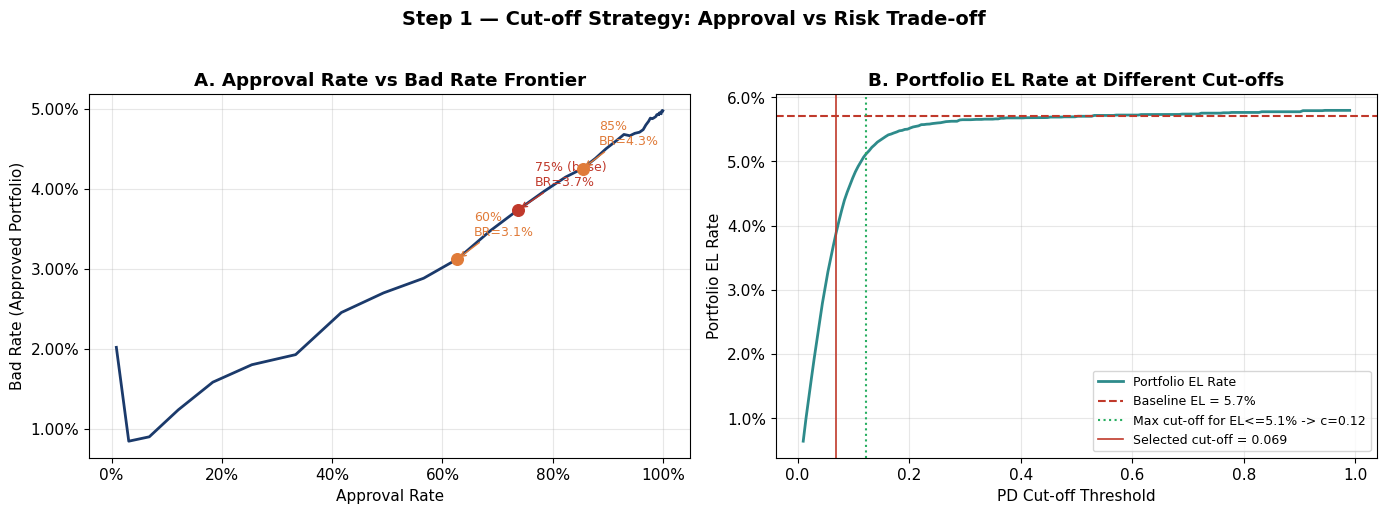

Saved: cutoff_strategy.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: frontier with 60/75/85% highlighted
ax = axes[0]
ax.plot(df_cutoff["approval_rate"], df_cutoff["bad_rate"], color=NAVY, linewidth=2)
highlight = {0.60: "60%", 0.75: "75% (base)", 0.85: "85%"}
for ar, label in highlight.items():
    r = df_cutoff.iloc[(df_cutoff["approval_rate"] - ar).abs().argsort()[:1]]
    x, y = r["approval_rate"].values[0], r["bad_rate"].values[0]
    color = RED if ar == 0.75 else ORANGE
    ax.scatter(x, y, color=color, zorder=5, s=70)
    ax.annotate(
        f"{label}\nBR={y:.1%}",
        xy=(x, y),
        xytext=(x + 0.03, y + 0.003),
        fontsize=9,
        color=color,
        arrowprops=dict(arrowstyle="->", color=color, lw=1),
    )
ax.set_xlabel("Approval Rate")
ax.set_ylabel("Bad Rate (Approved Portfolio)")
ax.set_title("A. Approval Rate vs Bad Rate Frontier", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Panel B: EL rate vs cut-off
ax2 = axes[1]
ax2.plot(
    df_cutoff["cutoff"],
    df_cutoff["el_rate"],
    color=TEAL,
    linewidth=2,
    label="Portfolio EL Rate",
)
ax2.axhline(
    actual_el, color=RED, linestyle="--", label=f"Baseline EL = {actual_el:.1%}"
)
el_target = actual_el * 0.90
opt = df_cutoff[df_cutoff["el_rate"] <= el_target]
if len(opt):
    opt_c = opt["cutoff"].max()
    ax2.axvline(
        opt_c,
        color=GREEN,
        linestyle=":",
        linewidth=1.5,
        label=f"Max cut-off for EL<={el_target:.1%} -> c={opt_c:.2f}",
    )
ax2.axvline(
    CUT_OFF,
    color=RED,
    linestyle="-",
    linewidth=1.2,
    label=f"Selected cut-off = {CUT_OFF:.3f}",
)
ax2.set_xlabel("PD Cut-off Threshold")
ax2.set_ylabel("Portfolio EL Rate")
ax2.set_title("B. Portfolio EL Rate at Different Cut-offs", fontweight="bold")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(fontsize=9)

plt.suptitle(
    "Step 1 — Cut-off Strategy: Approval vs Risk Trade-off",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("cutoff_strategy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cutoff_strategy.png")

# Apply cut-off decision
df_test["our_decision"] = np.where(df_test["pd_score"] < CUT_OFF, "Approve", "Reject")
df_test["lc_decision"] = "Approve"  # all loans in accepted dataset were LC-approved

---
## Step 2 — Risk-Based Pricing: *At What Rate?*

> **"Pricing is the monetization of risk"**

**Formula:** Required Rate = Funding Cost + Op Cost + PD × LGD + Margin

**Note on PD horizon:** We use `PD_12m` (one-year PD from Member A) as the annual EL add-on in the coupon. This is an annual-coupon approximation — not a lifetime pricing formula — so 36- and 60-month loans share the same annual premium structure. This is a conservative approximation for longer-term loans.

**Two-layer analysis:**
- **Layer A** (all LC-accepted loans): Is LC's pricing systematic? Any consistent bias?
- **Layer B** (our approved loans only): Which segments are being mispriced, and how should we act?

### 2-A. Compute Required Rate & Pricing Gap

In [11]:
FUNDING_COST = 0.035  # 3-yr Treasury + spread (2017 benchmark)
OP_COST = 0.010  # platform / origination operating cost
TARGET_MARGIN = 0.020  # required investor margin
# Capital charge excluded — simplified academic model

df_test["el_premium"] = df_test["pd_score"] * LGD_MEAN
df_test["required_rate"] = (
    FUNDING_COST + OP_COST + df_test["el_premium"] + TARGET_MARGIN
).clip(upper=0.50)
df_test["pricing_gap"] = df_test["int_rate_dec"] - df_test["required_rate"]
# Positive gap -> LC overpriced (good for investor) | Negative gap -> LC underpriced (risk not covered)

print("Pricing component summary:")
print(f"  Funding cost   : {FUNDING_COST:.2%}")
print(f"  Op cost        : {OP_COST:.2%}")
print(f"  Target margin  : {TARGET_MARGIN:.2%}")
print(f"  EL premium     : {df_test['el_premium'].mean():.2%}  (portfolio mean)")
print(f"  {'─'*35}")
print(f"  Required rate  : {df_test['required_rate'].mean():.2%}  (portfolio mean)")
print(f"  LC actual rate : {df_test['int_rate_dec'].mean():.2%}  (portfolio mean)")

Pricing component summary:
  Funding cost   : 3.50%
  Op cost        : 1.00%
  Target margin  : 2.00%
  EL premium     : 5.22%  (portfolio mean)
  ───────────────────────────────────
  Required rate  : 11.68%  (portfolio mean)
  LC actual rate : 12.98%  (portfolio mean)


### 2-B. Layer A — All LC-Accepted Loans: Systematic Mispricing?

In [12]:
all_underprice = df_test["pricing_gap"] < 0
print(f"[All {len(df_test):,} LC-accepted loans]")
print(
    f"  Underpriced (gap < 0) : {all_underprice.sum():,}  ({all_underprice.mean():.1%})"
)
print(
    f"  Overpriced  (gap > 0) : {(~all_underprice).sum():,}  ({(~all_underprice).mean():.1%})"
)
print(f"  Avg pricing gap       : {df_test['pricing_gap'].mean():.2%}")
print(
    "  -> LC pricing has a positive mean gap, but ~40% of loans are underpriced at the loan level"
)

[All 11,336 LC-accepted loans]
  Underpriced (gap < 0) : 4,516  (39.8%)
  Overpriced  (gap > 0) : 6,820  (60.2%)
  Avg pricing gap       : 1.30%
  -> LC pricing has a positive mean gap, but ~40% of loans are underpriced at the loan level


### 2-C. Plot: Required Rate vs LC Actual Rate (all LC loans)

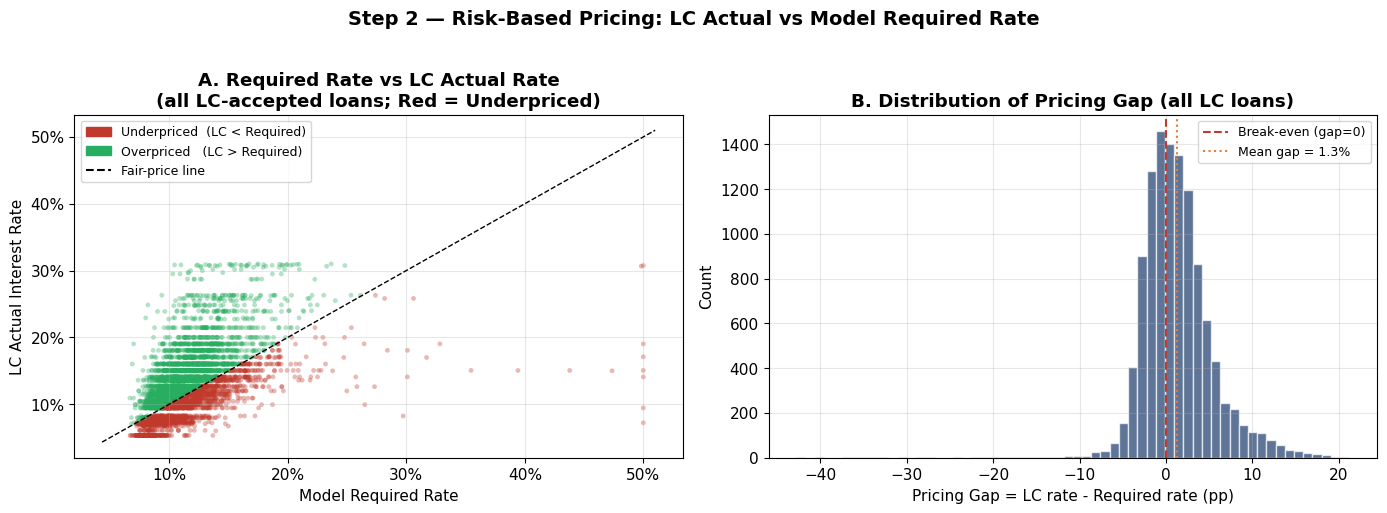

Saved: pricing_gap_scatter.png  <- KEY DELIVERABLE


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df_test.sample(min(5000, len(df_test)), random_state=42)
colors = [RED if g < 0 else GREEN for g in sample["pricing_gap"]]

ax = axes[0]
ax.scatter(
    sample["required_rate"],
    sample["int_rate_dec"],
    c=colors,
    alpha=0.35,
    s=12,
    linewidths=0,
)
lims = [
    min(sample["required_rate"].min(), sample["int_rate_dec"].min()) - 0.01,
    max(sample["required_rate"].max(), sample["int_rate_dec"].max()) + 0.01,
]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("Model Required Rate")
ax.set_ylabel("LC Actual Interest Rate")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title(
    "A. Required Rate vs LC Actual Rate\n(all LC-accepted loans; Red = Underpriced)",
    fontweight="bold",
)
ax.legend(
    handles=[
        Patch(color=RED, label="Underpriced  (LC < Required)"),
        Patch(color=GREEN, label="Overpriced   (LC > Required)"),
        plt.Line2D([0], [0], color="k", linestyle="--", label="Fair-price line"),
    ],
    fontsize=9,
)

ax2 = axes[1]
ax2.hist(
    df_test["pricing_gap"] * 100, bins=60, color=NAVY, alpha=0.7, edgecolor="white"
)
ax2.axvline(0, color=RED, linewidth=1.5, linestyle="--", label="Break-even (gap=0)")
ax2.axvline(
    df_test["pricing_gap"].mean() * 100,
    color=ORANGE,
    linewidth=1.5,
    linestyle=":",
    label=f"Mean gap = {df_test['pricing_gap'].mean():.1%}",
)
ax2.set_xlabel("Pricing Gap = LC rate - Required rate (pp)")
ax2.set_ylabel("Count")
ax2.set_title("B. Distribution of Pricing Gap (all LC loans)", fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle(
    "Step 2 — Risk-Based Pricing: LC Actual vs Model Required Rate",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("pricing_gap_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pricing_gap_scatter.png  <- KEY DELIVERABLE")

### 2-D. Layer B — Our Approved Loans: Segment-Level Mispricing

In [14]:
approved_test = df_test[df_test["our_decision"] == "Approve"].copy()
print(f"[Our approved loans: {len(approved_test):,}]")
print(f"  Underpriced : {(approved_test['pricing_gap'] < 0).mean():.1%}")
print(f"  Avg gap     : {approved_test['pricing_gap'].mean():.2%}")

if "purpose" in df_test.columns:
    seg_pricing = (
        approved_test.groupby("purpose")
        .agg(
            n_loans=("pricing_gap", "count"),
            avg_gap=("pricing_gap", "mean"),
            pct_underprice=("pricing_gap", lambda x: (x < 0).mean()),
            bad_rate=("target_bad", "mean"),
            avg_required=("required_rate", "mean"),
            avg_lc_rate=("int_rate_dec", "mean"),
        )
        .sort_values("avg_gap")
        .reset_index()
    )
    seg_pricing_display = seg_pricing.copy()
    for col in ["avg_gap", "pct_underprice", "bad_rate", "avg_required", "avg_lc_rate"]:
        seg_pricing_display[col] = seg_pricing_display[col].map("{:.2%}".format)
    print(
        "\n=== Pricing Gap by PURPOSE (our approved loans, most underpriced first) ==="
    )
    print(seg_pricing_display.to_string(index=False))
    seg_pricing.to_csv("pricing_by_purpose.csv", index=False)
    print("Saved: pricing_by_purpose.csv")

[Our approved loans: 8,364]
  Underpriced : 39.2%
  Avg gap     : 1.35%

=== Pricing Gap by PURPOSE (our approved loans, most underpriced first) ===
           purpose  n_loans avg_gap pct_underprice bad_rate avg_required avg_lc_rate
            moving       37   0.13%         54.05%    5.41%       10.87%      11.01%
           medical       86   0.30%         53.49%    9.30%       10.65%      10.95%
          vacation       63   0.32%         55.56%    7.94%       10.65%      10.97%
             house       39   0.50%         53.85%    5.13%       10.54%      11.04%
    major_purchase      180   0.53%         52.22%    2.78%       10.17%      10.70%
               car       97   0.57%         55.67%    0.00%       10.48%      11.05%
    small_business       79   0.61%         43.04%    6.33%       10.52%      11.13%
       credit_card     2141   1.22%         40.54%    4.34%        9.98%      11.20%
debt_consolidation     4297   1.42%         37.28%    3.26%       10.46%      11.89%
 

### 2-E. Plot: Underpriced Segments (% underpriced × bad rate)

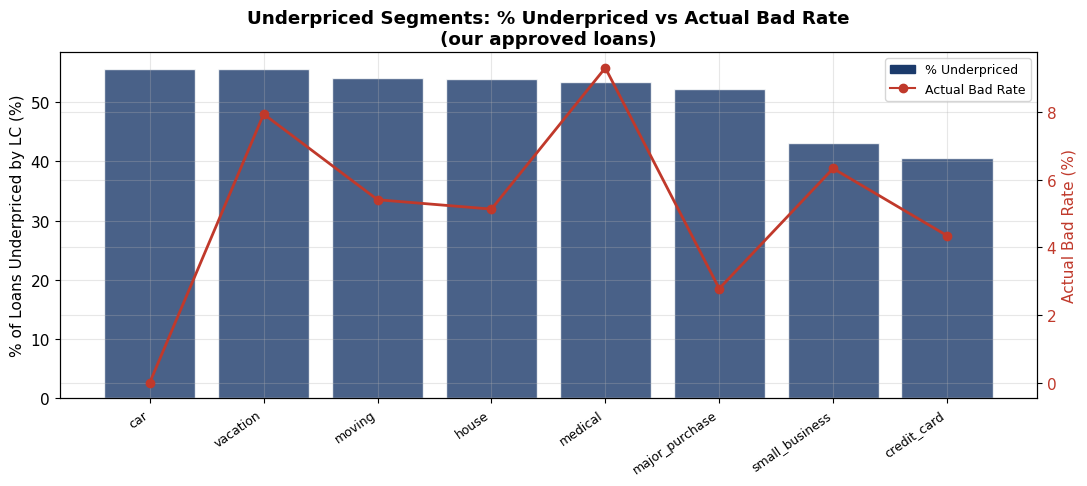

Saved: underpriced_segments.png


In [15]:
if "seg_pricing" in dir():
    seg_sorted = seg_pricing.sort_values("pct_underprice", ascending=False).head(8)
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(seg_sorted))
    ax.bar(
        x,
        seg_sorted["pct_underprice"] * 100,
        color=NAVY,
        alpha=0.8,
        edgecolor="white",
        label="% Underpriced",
    )
    ax2 = ax.twinx()
    ax2.plot(
        x,
        seg_sorted["bad_rate"] * 100,
        marker="o",
        color=RED,
        linewidth=2,
        label="Actual Bad Rate",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(seg_sorted["purpose"], rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("% of Loans Underpriced by LC (%)")
    ax2.set_ylabel("Actual Bad Rate (%)", color=RED)
    ax2.tick_params(axis="y", labelcolor=RED)
    ax.set_title(
        "Underpriced Segments: % Underpriced vs Actual Bad Rate\n(our approved loans)",
        fontweight="bold",
    )
    ax.legend(
        handles=[
            Patch(color=NAVY, label="% Underpriced"),
            plt.Line2D([0], [0], color=RED, marker="o", label="Actual Bad Rate"),
        ],
        fontsize=9,
    )
    plt.tight_layout()
    plt.savefig("underpriced_segments.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: underpriced_segments.png")

### 2-F. FICO × Grade Heatmap (60-month loans, our approved)

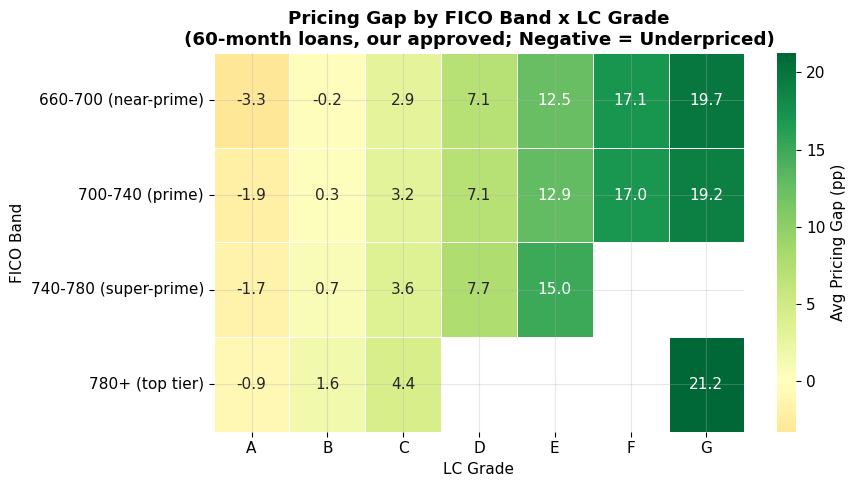

Saved: fico_grade_pricing_heatmap.png


In [16]:
fico_col = (
    "fico_range_low"
    if "fico_range_low" in df_test.columns
    else "fico_avg" if "fico_avg" in df_test.columns else None
)

if fico_col and "grade" in df_test.columns and "term_num" in df_test.columns:
    term60 = approved_test[approved_test["term_num"] == 60]
    if len(term60) > 100:
        hm = (
            term60.groupby(["fico_band", "grade"])["pricing_gap"]
            .mean()
            .unstack()
            .mul(100)
        )
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.heatmap(
            hm,
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            center=0,
            ax=ax,
            linewidths=0.5,
            cbar_kws={"label": "Avg Pricing Gap (pp)"},
        )
        ax.set_title(
            "Pricing Gap by FICO Band x LC Grade\n(60-month loans, our approved; Negative = Underpriced)",
            fontweight="bold",
        )
        ax.set_xlabel("LC Grade")
        ax.set_ylabel("FICO Band")
        plt.tight_layout()
        plt.savefig("fico_grade_pricing_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: fico_grade_pricing_heatmap.png")
    else:
        print("Not enough 60-month loans for heatmap")

---
## Step 3 — Swap-set Analysis: *How Does Our Strategy Differ from LC?*

Now that we know **(a) who to approve** and **(b) what rate to charge**, we compare our decisions to LC's:

- **Swap-Out** (risk filter): LC approved, we reject — high PD, high bad rate → validates our cut-off
- **Swap-In** (pricing opportunity): we approve AND LC overcharged vs our required rate (`pricing_gap > 2pp`) → validates our pricing
- **Both Approve**: aligned decisions

### 3-A. Define Swap Segments

In [18]:
SWAPIN_THRESHOLD = 0.02  # LC rate > required rate by >= 2pp -> genuine overcharge
SWAPIN_PD_MAX = 0.04


def swap_segment_label(row):
    if row["lc_decision"] == "Approve" and row["our_decision"] == "Reject":
        return "Swap-Out (risk filter)"
    elif row["lc_decision"] == "Approve" and row["our_decision"] == "Approve":
        return "Both Approve"
    return "Other"


df_test["swap_segment"] = df_test.apply(swap_segment_label, axis=1)

# Swap-in: within our-approved, LC charged significantly more than required
df_test["is_swap_in"] = (
    (df_test["our_decision"] == "Approve")
    & (df_test["pricing_gap"] > SWAPIN_THRESHOLD)
    & (df_test["pd_score"] < SWAPIN_PD_MAX)
).astype(int)

swap_in = df_test[df_test["is_swap_in"] == 1]
swap_out = df_test[df_test["swap_segment"] == "Swap-Out (risk filter)"]
both_app = df_test[df_test["swap_segment"] == "Both Approve"]

print("Segment counts:")
print(df_test["swap_segment"].value_counts())
print(
    f"\nSwap-in (we approve, LC overcharged >={SWAPIN_THRESHOLD:.0%}): {len(swap_in):,}"
)
print(f"  Avg model PD    : {swap_in['pd_score'].mean():.3f}")
print(f"  Avg LC int_rate : {swap_in['int_rate_dec'].mean():.2%}")
print(f"  Avg pricing gap : {swap_in['pricing_gap'].mean():.2%}")
print(f"  Actual bad rate : {swap_in['target_bad'].mean():.2%}")

Segment counts:
swap_segment
Both Approve              8364
Swap-Out (risk filter)    2972
Name: count, dtype: int64

Swap-in (we approve, LC overcharged >=2%): 1,060
  Avg model PD    : 0.029
  Avg LC int_rate : 13.79%
  Avg pricing gap : 4.59%
  Actual bad rate : 2.83%


### 3-B. Swap-Out Bad Rate by Loan Purpose

In [19]:
if "purpose" in df_test.columns:
    swap_out_purpose = (
        swap_out.groupby("purpose")
        .agg(
            n_loans=("target_bad", "count"),
            bad_rate=("target_bad", "mean"),
            avg_pd=("pd_score", "mean"),
        )
        .sort_values("bad_rate", ascending=False)
        .reset_index()
    )
    both_purpose = (
        both_app.groupby("purpose")
        .agg(bad_rate_both=("target_bad", "mean"))
        .reset_index()
    )
    swap_vs_both = swap_out_purpose.merge(both_purpose, on="purpose", how="left")
    swap_vs_both["bad_rate_lift"] = (
        swap_vs_both["bad_rate"] - swap_vs_both["bad_rate_both"]
    )
    print("=== Swap-Out Bad Rate by Purpose ===")
    print(
        swap_vs_both[
            ["purpose", "n_loans", "bad_rate", "bad_rate_both", "bad_rate_lift"]
        ].to_string(index=False)
    )
    swap_vs_both.to_csv("swapout_by_purpose.csv", index=False)

=== Swap-Out Bad Rate by Purpose ===
           purpose  n_loans  bad_rate  bad_rate_both  bad_rate_lift
    small_business       54  0.129630       0.063291       0.066338
             other      241  0.099585       0.027157       0.072429
       credit_card      332  0.087349       0.043438       0.043912
debt_consolidation     1904  0.087185       0.032581       0.054604
            moving       58  0.086207       0.054054       0.032153
    major_purchase       65  0.076923       0.027778       0.049145
  home_improvement      129  0.069767       0.050350       0.019418
          vacation       43  0.046512       0.079365      -0.032853
           medical       68  0.044118       0.093023      -0.048906
               car       37  0.027027       0.000000       0.027027
             house       34  0.000000       0.051282      -0.051282
  renewable_energy        7  0.000000       0.000000       0.000000


### 3-C. Swap-set Summary Table

In [38]:
agg_cols = {
    k: v
    for k, v in {
        "target_bad": ["count", "mean"],
        "pd_score": "mean",
        "int_rate_dec": "mean",
        "pricing_gap": "mean",
        "EAD": "sum",
    }.items()
    if k in df_test.columns
}

df_test["swap_segment_detail"] = df_test["swap_segment"].copy()
df_test.loc[df_test["is_swap_in"] == 1, "swap_segment_detail"] = (
    "Swap-In (pricing opportunity)"
)

swap_table = df_test.groupby("swap_segment_detail").agg(agg_cols).round(4)

swap_table.columns = [
    "_".join(c).strip() if isinstance(c, tuple) else c for c in swap_table.columns
]
swap_table = swap_table.rename(
    columns={
        "target_bad_count": "n_loans",
        "target_bad_mean": "actual_bad_rate",
        "pd_score_mean": "avg_model_pd",
        "int_rate_dec_mean": "avg_lc_int_rate",
        "pricing_gap_mean": "avg_pricing_gap",
        "EAD_sum": "total_EAD",
    }
)
print("=== Swap-set Summary Table ===")
print(swap_table.to_string())
swap_table.to_csv("swapset_summary_table.csv")
print("Saved: swapset_summary_table.csv")

=== Swap-set Summary Table ===
                               n_loans  actual_bad_rate  avg_model_pd  avg_lc_int_rate  avg_pricing_gap    total_EAD
swap_segment_detail                                                                                                 
Both Approve                      7304           0.0387        0.0431           0.1132           0.0088  59544580.56
Swap-In (pricing opportunity)     1060           0.0283        0.0295           0.1379           0.0459   8949986.68
Swap-Out (risk filter)            2972           0.0845        0.1014           0.1677           0.0116  34442166.37
Saved: swapset_summary_table.csv


### 3-D. Plots: Swap-set Composition & Bad Rate by Purpose

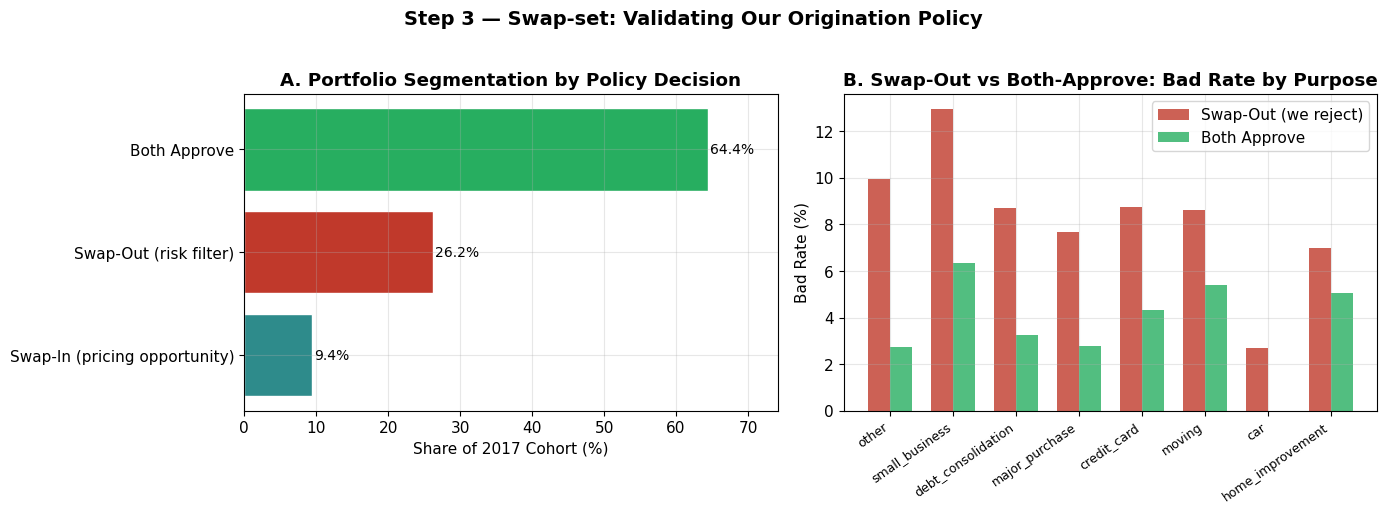

Saved: swapset_analysis.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: segment composition
seg_pct = (
    df_test["swap_segment_detail"].value_counts(normalize=True) * 100
).sort_values()
colors_seg = [
    GREEN if "Both" in s else TEAL if "Swap-In" in s else RED for s in seg_pct.index
]
axes[0].barh(seg_pct.index, seg_pct.values, color=colors_seg, edgecolor="white")
for i, v in enumerate(seg_pct.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)
axes[0].set_xlabel("Share of 2017 Cohort (%)")
axes[0].set_title("A. Portfolio Segmentation by Policy Decision", fontweight="bold")
axes[0].set_xlim(0, max(seg_pct.values) * 1.15)

# Panel B: bad rate by purpose
if "purpose" in df_test.columns and "swap_vs_both" in dir():
    top_n = swap_vs_both.nlargest(8, "bad_rate_lift")
    x, w = np.arange(len(top_n)), 0.35
    axes[1].bar(
        x - w / 2,
        top_n["bad_rate"] * 100,
        width=w,
        label="Swap-Out (we reject)",
        color=RED,
        alpha=0.8,
    )
    axes[1].bar(
        x + w / 2,
        top_n["bad_rate_both"] * 100,
        width=w,
        label="Both Approve",
        color=GREEN,
        alpha=0.8,
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(top_n["purpose"], rotation=35, ha="right", fontsize=9)
    axes[1].set_ylabel("Bad Rate (%)")
    axes[1].set_title(
        "B. Swap-Out vs Both-Approve: Bad Rate by Purpose", fontweight="bold"
    )
    axes[1].legend()

plt.suptitle(
    "Step 3 — Swap-set: Validating Our Origination Policy",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("swapset_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: swapset_analysis.png")

### 3-E. Plot: Swap-In Opportunity Overview

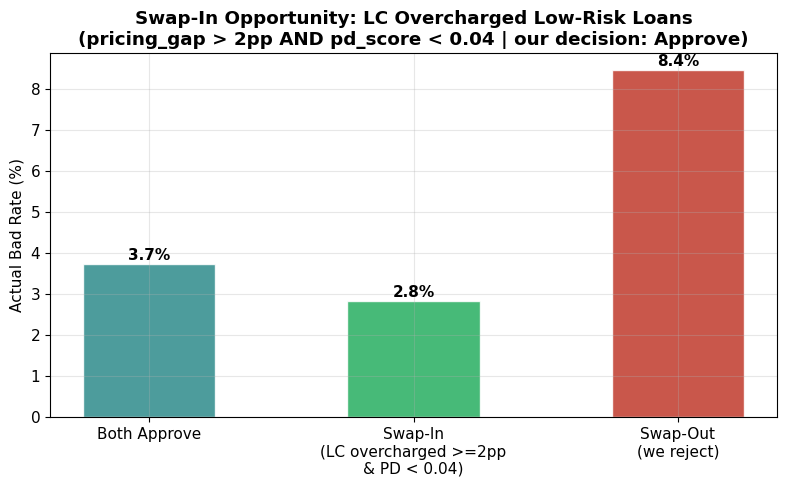

Saved: swapin_overview.png


In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
groups = [
    "Both Approve",
    "Swap-In\n(LC overcharged >=2pp\n& PD < 0.04)",
    "Swap-Out\n(we reject)",
]
bad_rates = [
    both_app["target_bad"].mean() * 100,
    swap_in["target_bad"].mean() * 100,
    swap_out["target_bad"].mean() * 100,
]
colors_bar = [TEAL, GREEN, RED]
bars = ax.bar(
    groups, bad_rates, color=colors_bar, alpha=0.85, edgecolor="white", width=0.5
)
for bar, v in zip(bars, bad_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.1,
        f"{v:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
ax.set_ylabel("Actual Bad Rate (%)")
ax.set_title(
    "Swap-In Opportunity: LC Overcharged Low-Risk Loans\n"
    "(pricing_gap > 2pp AND pd_score < 0.04 | our decision: Approve)",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("swapin_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: swapin_overview.png")

---
## Step 4 — Portfolio Simulation: *What Is the Impact?*

Simulate the 2017 cohort under **LC baseline** (approve all) vs **our policy** (cut-off + risk pricing).

> ⚠️ **Note:** "Predicted EL" = model `pd_score × LGD × EAD`. This is a forward-looking estimate, not realized loss. Actual Defaults is the observed outcome; Predicted EL and Actual Defaults should not be directly compared as if they measure the same thing.

In [25]:
cohort = df_test.copy()

# LC baseline: approve all
lc_defaults = int(cohort["target_bad"].sum())
lc_bad_rate = cohort["target_bad"].mean()
lc_total_ead = cohort["EAD"].sum()
lc_pred_el = (cohort["pd_score"] * LGD_MEAN * cohort["EAD"]).sum()  # Predicted EL

# Our policy: apply cut-off
our_approved = cohort[cohort["pd_score"] < CUT_OFF]
our_rejected = cohort[cohort["pd_score"] >= CUT_OFF]
our_defaults = int(our_approved["target_bad"].sum())
our_bad_rate = our_approved["target_bad"].mean()
our_total_ead = our_approved["EAD"].sum()
our_pred_el = (
    our_approved["pd_score"] * LGD_MEAN * our_approved["EAD"]
).sum()  # Predicted EL

el_saved = lc_pred_el - our_pred_el
avoided_defaults = lc_defaults - our_defaults

lc_realized_loss = cohort["realized_loss"].sum()
our_realized_loss = our_approved["realized_loss"].sum()
realized_reduction = lc_realized_loss - our_realized_loss


print("=== 2017 COHORT SIMULATION RESULTS ===")
print(f'{"Metric":<35} {"LC Baseline":>15} {"Our Policy":>15} {"Delta":>15}')
print("-" * 80)
print(
    f'{"Loans Approved":<35} {len(cohort):>15,} {len(our_approved):>15,} {-len(our_rejected):>+15,}'
)
print(
    f'{"Loans Rejected":<35} {"0":>15} {len(our_rejected):>15,} {len(our_rejected):>+15,}'
)
print(
    f'{"Actual Defaults":<35} {lc_defaults:>15,} {our_defaults:>15,} {-avoided_defaults:>+15,}'
)
print(
    f'{"Portfolio Bad Rate":<35} {lc_bad_rate:>15.2%} {our_bad_rate:>15.2%} {our_bad_rate-lc_bad_rate:>+15.2%}'
)
print(
    f'{"Total EAD ($)":<35} {lc_total_ead:>15,.0f} {our_total_ead:>15,.0f} {our_total_ead-lc_total_ead:>+15,.0f}'
)
print(
    f'{"Predicted EL ($)":<35} {lc_pred_el:>15,.0f} {our_pred_el:>15,.0f} {-el_saved:>+15,.0f}'
)
print(
    f'{"Realized Loss ($)":<35} {lc_realized_loss:>15,.0f} {our_realized_loss:>15,.0f} {-realized_reduction:>+15,.0f}'
)
print(f"\nPredicted EL reduction : ${el_saved:,.0f}  ({el_saved/lc_pred_el:.1%})")
print(
    f"Realized Loss reduction : ${realized_reduction:,.0f}  ({realized_reduction/lc_realized_loss:.1%})"
)
print("(Assumption: rejected loans generate zero realized loss)")

=== 2017 COHORT SIMULATION RESULTS ===
Metric                                  LC Baseline      Our Policy           Delta
--------------------------------------------------------------------------------
Loans Approved                               11,336           8,364          -2,972
Loans Rejected                                    0           2,972          +2,972
Actual Defaults                                 564             313            -251
Portfolio Bad Rate                            4.98%           3.74%          -1.23%
Total EAD ($)                           102,936,734      68,494,567     -34,442,166
Predicted EL ($)                          6,025,186       2,663,761      -3,361,426
Realized Loss ($)                         6,115,027       2,949,689      -3,165,338

Predicted EL reduction : $3,361,426  (55.8%)
Realized Loss reduction : $3,165,338  (51.8%)
(Assumption: rejected loans generate zero realized loss)


In [41]:
print(f"\n--- Portfolio-Level Pricing Validation ---")
total_required_income = (our_approved["required_rate"] * our_approved["EAD"]).sum()
total_realized_loss_approved = our_approved["realized_loss"].sum()
coverage_ratio = total_required_income / total_realized_loss_approved
print(f"  Required interest income : ${total_required_income:,.0f}")
print(f"  Realized loss (approved) : ${total_realized_loss_approved:,.0f}")
print(f"  Coverage ratio           : {coverage_ratio:.2f}x")
print(f"  -> Our required rate covers {coverage_ratio:.1f}x actual losses")
print(f"     (Primary pricing validation — portfolio level)")


--- Portfolio-Level Pricing Validation ---
  Required interest income : $7,115,908
  Realized loss (approved) : $2,949,689
  Coverage ratio           : 2.41x
  -> Our required rate covers 2.4x actual losses
     (Primary pricing validation — portfolio level)


### 4-A. Plot: Simulation Bar Charts

### 4-B. Supplemental: Pricing Adequacy Backtest (Stress View)

> This is a **stress-style realized-loss check**, not the primary pricing validation.  
> Our pricing is designed to cover **expected loss at the portfolio level**.  
> Single-default adequacy is naturally low — the EL framework distributes risk across the portfolio, not loan-by-loan.

In [30]:
df_test["annual_loss_rate"] = (
    df_test["realized_loss"] / df_test["EAD"].clip(lower=1) / (df_test["term_num"] / 12)
)
df_test["pricing_adequate"] = df_test["required_rate"] >= df_test["annual_loss_rate"]
defaulters = df_test[df_test["target_bad"] == 1]

print("=== [Supplemental] Pricing Adequacy Backtest ===")
print(f"\nFull portfolio ({len(df_test):,} loans):")
print(f"  Avg required rate    : {df_test['required_rate'].mean():.2%}")
print(f"  Avg annual loss rate : {df_test['annual_loss_rate'].mean():.2%}")
print(f"  Pricing adequate     : {df_test['pricing_adequate'].mean():.1%}")
print(f"\nDefaulted loans ({len(defaulters):,}) <- stress view:")
print(f"  Adequate             : {defaulters['pricing_adequate'].mean():.1%}")
print("  Note: low adequacy on defaulted loans is expected — EL framework is")
print("  designed for portfolio-level coverage, not single-loan loss absorption.")

if "grade" in df_test.columns:
    grade_order = ["A", "B", "C", "D", "E", "F", "G"]
    grade_backtest = (
        defaulters.groupby("grade")
        .agg(
            n_defaults=("target_bad", "count"),
            avg_required=("required_rate", "mean"),
            avg_annual_loss=("annual_loss_rate", "mean"),
            pct_adequate=("pricing_adequate", "mean"),
        )
        .reindex(grade_order)
        .dropna()
    )
    grade_backtest["gap"] = (
        grade_backtest["avg_required"] - grade_backtest["avg_annual_loss"]
    )
    print("\n=== Pricing Adequacy by Grade (defaulted loans) ===")
    print(grade_backtest.round(4).to_string())

=== [Supplemental] Pricing Adequacy Backtest ===

Full portfolio (11,336 loans):
  Avg required rate    : 11.68%
  Avg annual loss rate : 1.37%
  Pricing adequate     : 95.2%

Defaulted loans (564) <- stress view:
  Adequate             : 4.4%
  Note: low adequacy on defaulted loans is expected — EL framework is
  designed for portfolio-level coverage, not single-loan loss absorption.

=== Pricing Adequacy by Grade (defaulted loans) ===
       n_defaults  avg_required  avg_annual_loss  pct_adequate     gap
grade                                                                 
A              23        0.0950           0.3230        0.0000 -0.2280
B             108        0.1114           0.2980        0.0000 -0.1866
C             222        0.1271           0.2661        0.0135 -0.1390
D             123        0.1418           0.2753        0.0732 -0.1335
E              55        0.1429           0.2630        0.0727 -0.1201
F              21        0.2058           0.2389        0.2857

---
## Step 5 — Grade System Evaluation

**Questions:**
1. Is LC's A–G grading monotonically predictive of bad rate?
2. Does our model add finer risk discrimination *within* each grade?

### 5-A. LC Grade vs Model Performance

In [33]:
if "grade" in df_test.columns:
    grade_order = ["A", "B", "C", "D", "E", "F", "G"]
    df_test["grade_str"] = df_test["grade"].astype(str).str.strip().str.upper()
    valid_grades = df_test[df_test["grade_str"].isin(grade_order)].copy()

    grade_stats = (
        valid_grades.groupby("grade_str")
        .agg(
            n_loans=("target_bad", "count"),
            actual_br=("target_bad", "mean"),
            avg_model_pd=("pd_score", "mean"),
            avg_lc_rate=("int_rate_dec", "mean"),
            avg_req_rate=("required_rate", "mean"),
        )
        .reindex(grade_order)
        .dropna()
        .reset_index()
        .rename(columns={"grade_str": "grade"})
    )
    print("=== LC Grade vs Model Performance ===")
    print(grade_stats.round(4).to_string(index=False))

=== LC Grade vs Model Performance ===
grade  n_loans  actual_br  avg_model_pd  avg_lc_rate  avg_req_rate
    A     2026     0.0114        0.0297       0.0694        0.0918
    B     3470     0.0311        0.0470       0.1051        0.1078
    C     3846     0.0577        0.0650       0.1423        0.1241
    D     1390     0.0885        0.0794       0.1873        0.1367
    E      434     0.1267        0.0965       0.2469        0.1524
    F      110     0.1909        0.1252       0.2983        0.1792
    G       60     0.2000        0.1341       0.3048        0.1797


### 5-B. Plot: Three-Panel Grade Comparison

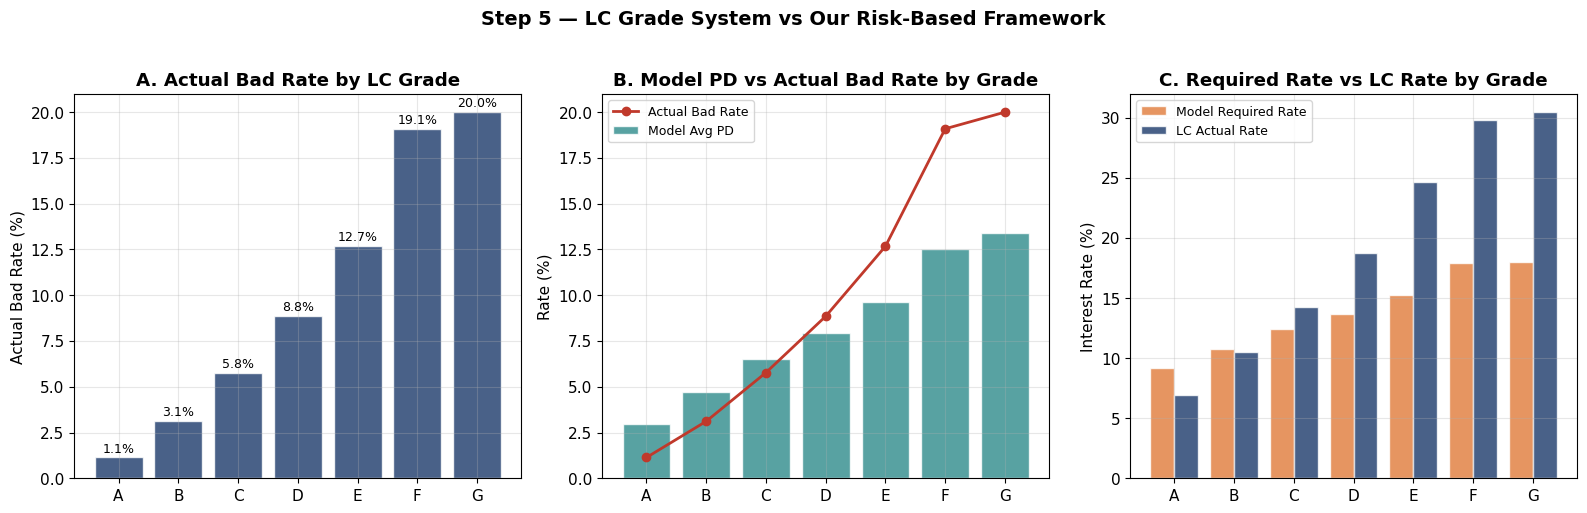

Saved: grade_comparison.png


In [37]:
if "grade_stats" in dir() and len(grade_stats) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    grades = grade_stats["grade"].tolist()
    x = np.arange(len(grades))

    # Panel A: monotonicity of actual bad rate
    bars = axes[0].bar(
        grades, grade_stats["actual_br"] * 100, color=NAVY, alpha=0.8, edgecolor="white"
    )
    axes[0].set_ylabel("Actual Bad Rate (%)")
    axes[0].set_title("A. Actual Bad Rate by LC Grade", fontweight="bold")
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%",
            ha="center",
            fontsize=9,
        )

    # Panel B: model PD vs actual bad rate
    axes[1].bar(
        grades,
        grade_stats["avg_model_pd"] * 100,
        color=TEAL,
        alpha=0.8,
        edgecolor="white",
        label="Model Avg PD",
    )
    axes[1].plot(
        grades,
        grade_stats["actual_br"] * 100,
        marker="o",
        color=RED,
        linewidth=2,
        label="Actual Bad Rate",
    )
    axes[1].set_ylabel("Rate (%)")
    axes[1].set_title("B. Model PD vs Actual Bad Rate by Grade", fontweight="bold")
    axes[1].legend(fontsize=9)

    # Panel C: required rate vs LC rate
    axes[2].bar(
        x - 0.2,
        grade_stats["avg_req_rate"] * 100,
        0.4,
        label="Model Required Rate",
        color=ORANGE,
        alpha=0.8,
        edgecolor="white",
    )
    axes[2].bar(
        x + 0.2,
        grade_stats["avg_lc_rate"] * 100,
        0.4,
        label="LC Actual Rate",
        color=NAVY,
        alpha=0.8,
        edgecolor="white",
    )
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(grades)
    axes[2].set_ylabel("Interest Rate (%)")
    axes[2].set_title("C. Required Rate vs LC Rate by Grade", fontweight="bold")
    axes[2].legend(fontsize=9)

    plt.suptitle(
        "Step 5 — LC Grade System vs Our Risk-Based Framework",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig("grade_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: grade_comparison.png")

### 5-C. Within-Grade Gini: Does Our Model Add Value Beyond LC Grading?

In [36]:
if "valid_grades" in dir():
    within_grade = []
    for g in grade_order:
        sub = valid_grades[valid_grades["grade_str"] == g]
        if sub["target_bad"].nunique() < 2 or len(sub) < 50:
            continue
        auc = roc_auc_score(sub["target_bad"], sub["pd_score"])
        gini = 2 * auc - 1
        within_grade.append(
            {"grade": g, "n": len(sub), "AUC": round(auc, 3), "Gini": round(gini, 3)}
        )
    df_within = pd.DataFrame(within_grade)
    print("=== Within-Grade Model Discrimination ===")
    print(df_within.to_string(index=False))
    print("\n-> Positive Gini within most grades = our model captures finer risk")
    print("   distinctions that LC's A-G system misses.")

=== Within-Grade Model Discrimination ===
grade    n   AUC   Gini
    A 2026 0.548  0.095
    B 3470 0.557  0.115
    C 3846 0.568  0.137
    D 1390 0.564  0.127
    E  434 0.418 -0.164
    F  110 0.556  0.113
    G   60 0.536  0.073

-> Positive Gini within most grades = our model captures finer risk
   distinctions that LC's A-G system misses.


---
## Deliverables Summary

| Step | File | Description |
|------|------|-------------|
| Step 1 | `cutoff_strategy.png` | Frontier + three operating points |
| Step 1 | `cutoff_summary_table.csv` | 60/75/85% operating point table |
| Step 2 | `pricing_gap_scatter.png` | Required vs actual rate (all LC loans) |
| Step 2 | `underpriced_segments.png` | Segment mispricing + bad rate |
| Step 2 | `pricing_by_purpose.csv` | Per-purpose gap table |
| Step 2 | `fico_grade_pricing_heatmap.png` | FICO × Grade heatmap |
| Step 3 | `swapset_analysis.png` | Composition + bad rate by purpose |
| Step 3 | `swapin_overview.png` | Swap-in opportunity bar chart |
| Step 3 | `swapset_summary_table.csv` | Segment summary |
| Step 3 | `swapout_by_purpose.csv` | Swap-out by purpose |
| Step 4 | `simulation_2017.png` | Volume / defaults / predicted EL |
| Step 5 | `grade_comparison.png` | Monotonicity + rate gap |